In [1]:
import os, glob
import torch
import nugraph as ng

torch.set_float32_matmul_precision("medium")

DATA_PATH = "/home/apaudel/NuGraph/scripts/merged1_July21_40k_pmtpmt"
RUN_NAME = "merged1_Aug18_MAIN_prenexus_on_July21_40k_pmtpmt_no_lepdir_ep45_bs64_in8"

ckpts = glob.glob(f"/home/apaudel/NuGraph/logs/{RUN_NAME}/**/*.ckpt", recursive=True)
assert ckpts, f"No checkpoint found for {RUN_NAME}"

CKPT = max(ckpts, key=os.path.getmtime)
print("Using checkpoint:")
print(CKPT)

Data = ng.data.H5DataModule
Model = ng.models.NuGraph3

nudata = Data(
    DATA_PATH,
    batch_size=64,
    num_workers=0,
    model=Model,
    shuffle="random",
)

model = Model.load_from_checkpoint(CKPT)
model.eval()

print("event_classes:", nudata.event_classes)
print("semantic_classes:", nudata.semantic_classes)
print("test events:", len(nudata.test_dataset))

Using checkpoint:
/home/apaudel/NuGraph/logs/merged1_Aug18_MAIN_prenexus_on_July21_40k_pmtpmt_no_lepdir_ep45_bs64_in8/version_0/checkpoints/epoch=44-step=21105.ckpt
event_classes: ['cc_nue', 'es_nue']
semantic_classes: ['pion', 'muon', 'kaon', 'hadron', 'shower', 'lowE_electron', 'michel', 'diffuse']
test events: 1669


Classes: ['cc_nue', 'es_nue']

Counts:


,Pred ES,Pred CC
True CC,141,805
True ES,595,128



Row-normalized fractions:


,Pred ES,Pred CC
True CC,0.149,0.851
True ES,0.823,0.177



Overall accuracy = 0.8388
CC classified as CC = 0.8510
ES classified as ES = 0.8230


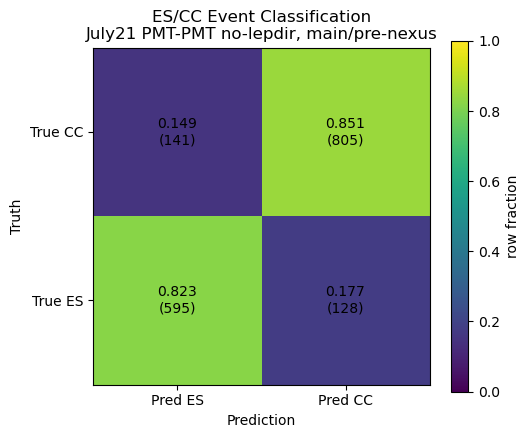

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

ys, ps, probs_all = [], [], []

loader = nudata.test_dataloader()

with torch.no_grad():
    for batch in loader:
        batch = batch.to(device)

        # Runs model and EventDecoder writes probabilities into batch["evt"].e
        model(batch)

        y = batch["evt"].y.detach().cpu().view(-1)
        probs = batch["evt"].e.detach().cpu()
        pred = probs.argmax(dim=1)

        ys.append(y.numpy())
        ps.append(pred.numpy())
        probs_all.append(probs.numpy())

y_true = np.concatenate(ys)
y_pred = np.concatenate(ps)
probs_all = np.concatenate(probs_all)

classes = list(nudata.event_classes)
print("Classes:", classes)

cc_idx = [i for i, c in enumerate(classes) if "cc" in c.lower()][0]
es_idx = [i for i, c in enumerate(classes) if "es" in c.lower()][0]

# Requested layout:
# Y axis true: CC, ES
# X axis pred: ES, CC
row_order = [cc_idx, es_idx]
col_order = [es_idx, cc_idx]
row_names = ["True CC", "True ES"]
col_names = ["Pred ES", "Pred CC"]

cm = np.zeros((2, 2), dtype=int)

for i, yt in enumerate(row_order):
    for j, yp in enumerate(col_order):
        cm[i, j] = np.sum((y_true == yt) & (y_pred == yp))

cm_frac = cm / cm.sum(axis=1, keepdims=True)

df_counts = pd.DataFrame(cm, index=row_names, columns=col_names)
df_frac = pd.DataFrame(cm_frac, index=row_names, columns=col_names)

print("\nCounts:")
display(df_counts)

print("\nRow-normalized fractions:")
display(df_frac.round(4))

acc = np.mean(y_true == y_pred)
cc_eff = cm[0, 1] / cm[0].sum()
es_eff = cm[1, 0] / cm[1].sum()

print(f"\nOverall accuracy = {acc:.4f}")
print(f"CC classified as CC = {cc_eff:.4f}")
print(f"ES classified as ES = {es_eff:.4f}")

plt.figure(figsize=(5.4, 4.5))
plt.imshow(cm_frac, vmin=0, vmax=1)
plt.xticks(range(2), col_names)
plt.yticks(range(2), row_names)
plt.colorbar(label="row fraction")

for i in range(2):
    for j in range(2):
        plt.text(
            j, i,
            f"{cm_frac[i,j]:.3f}\n({cm[i,j]})",
            ha="center",
            va="center",
        )

plt.title("ES/CC Event Classification\nJuly21 PMT-PMT no-lepdir, main/pre-nexus")
plt.xlabel("Prediction")
plt.ylabel("Truth")
plt.tight_layout()
plt.show()